<a href="https://colab.research.google.com/github/kundana12345/DataScience/blob/main/Kundana_MultLinExercises.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install bambi

In [2]:
from google.colab import files
from google.colab.output import eval_js
import io
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import graphviz as gv
import arviz as az
import pymc as pm
import bambi as bmb

## Exercises

You may use whatever resources you want to complete these exercises, so long as you cite your sources and the use of AI.

I recommend copying and pasting from the examples I did [here](https://github.com/thedarredondo/data-science-fundamentals/blob/main/FastTrack/IntroMultLinSF.ipynb); giving you something to copy and paste from was half my intent in writing that lesson.

**Task1**

Get the [penguins data from my github page](https://github.com/thedarredondo/data-science-fundamentals/blob/main/Data/penguins.csv) into this colab document.

I suggest downloading the csv, and then using the code from [notes document](https://github.com/thedarredondo/data-science-fundamentals/blob/main/FastTrack/IntroMultLinSF.ipynb) to upload it into this jupyter notebook.

In [3]:
url="https://raw.githubusercontent.com/thedarredondo/data-science-fundamentals/main/Data/penguins.csv"
penguins = pd.read_csv(url)

In [4]:
penguins

,species,island,bill_length,bill_depth,flipper_length,body_mass,sex,year
0,Adelie,Torgersen,3.91,1.87,18.1,3.750,male,2007
1,Adelie,Torgersen,3.95,1.74,18.6,3.800,female,2007
2,Adelie,Torgersen,4.03,1.80,19.5,3.250,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,3.67,1.93,19.3,3.450,female,2007
...,...,...,...,...,...,...,...,...
339,Chinstrap,Dream,5.58,1.98,20.7,4.000,male,2009
340,Chinstrap,Dream,4.35,1.81,20.2,3.400,female,2009
341,Chinstrap,Dream,4.96,1.82,19.3,3.775,male,2009
342,Chinstrap,Dream,5.08,1.90,21.0,4.100,male,2009


**Task2**

Make a pair plot with the penguins data and describe the scatter plots. Make sure to describe any patterns.

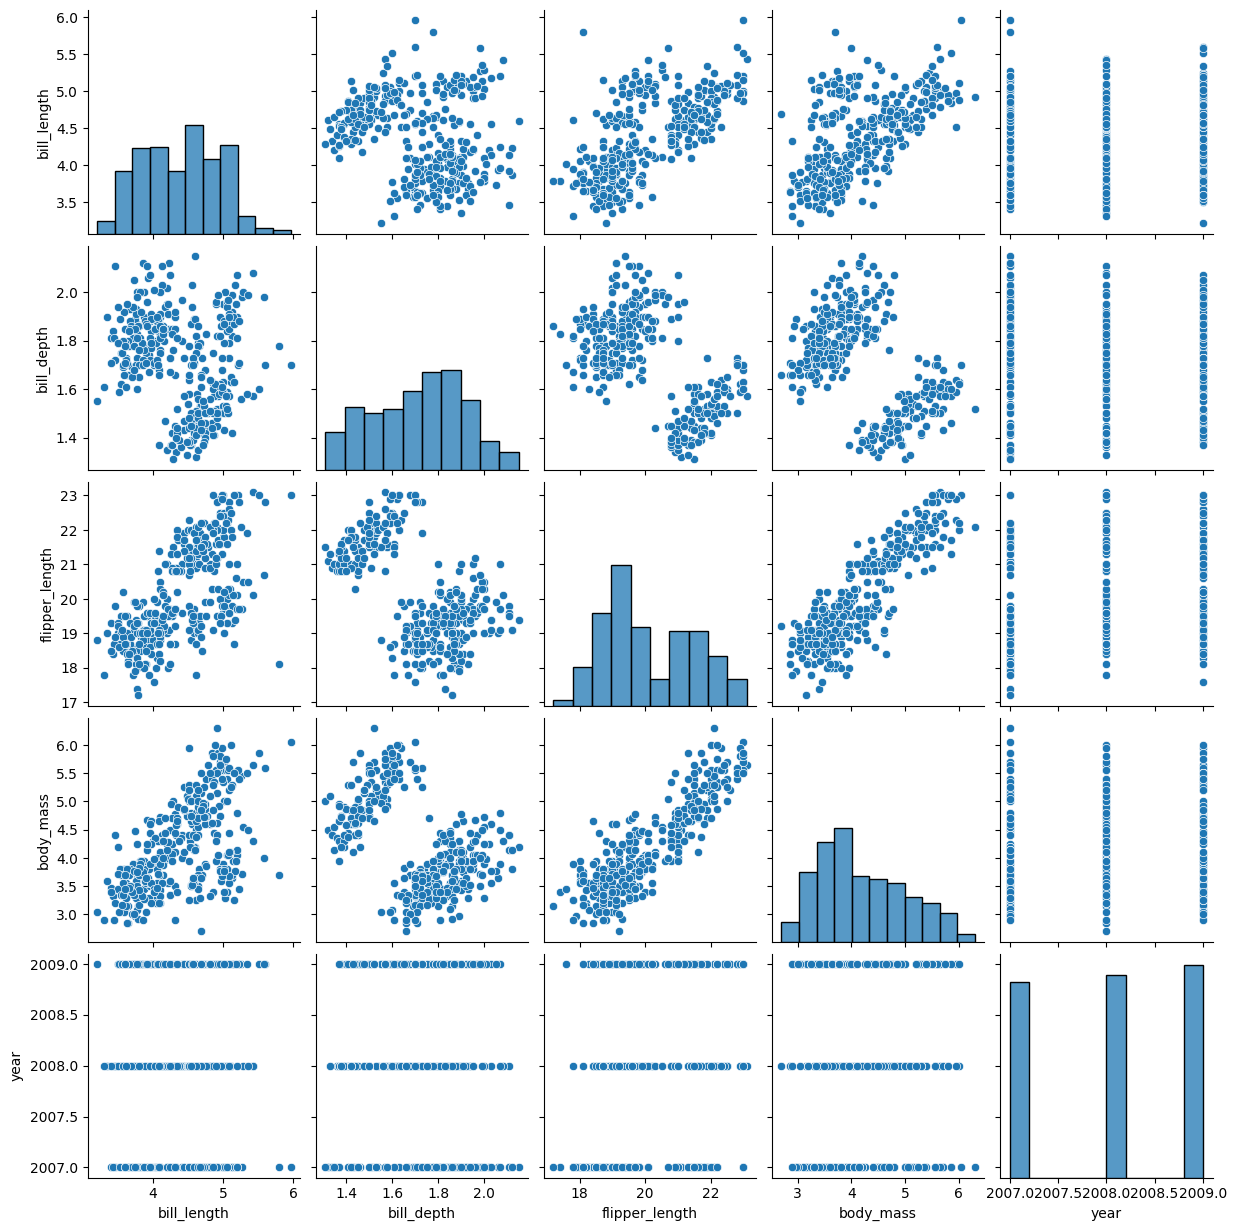

In [5]:
sns.pairplot(penguins)

linear for bill length vs. mass, depth vs. mass, flipper length vs. mass, depth vs. flipper length, bill lenght vs. flipper length, depth vs. both lengths
There are two clusters in all the linear plots, they might represent different species or males and females. But flipper length vs. mass doesn't have two clusters. Year seems irrelevant.

**Task3**

Make a causal diagram corresponding to the penguins data. Remember to include the species variable, even though it likely didn't show up in your pair plot.

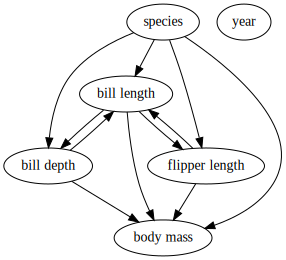

In [9]:
s_dag = gv.Digraph(name="Penguins")

s_dag.node('L','bill length')
s_dag.node('D','bill depth')
s_dag.node('F','flipper length')
s_dag.node('M','body mass')
s_dag.node('S','species')
s_dag.node('Y','year')

s_dag.edges(['LD','LF','LM','DL', 'FL', 'DM', 'FM', 'SM', 'SL', 'SD', 'SF'])

s_dag

**Task4**

Create a Bayesian generalized linear model (GLM) to represent and test your causal diagram.

Then, conduct both types of posterior predictve check, and use them to comment on the model's fit. Note that you may want to make several plots here.

You may use another model type if want--[such as BART](https://github.com/thedarredondo/data-science-fundamentals/blob/main/Unit8/Unit8NotesSF.ipynb)--so long as it is Bayesian, and it represents your causal diagram.

In [ ]:
#used gemini to add dropna thing

In [13]:
model_body = bmb.Model("body_mass ~ bill_depth + flipper_length + bill_length + species:bill_depth + bill_length", data = penguins, dropna=True)

In [ ]:
idata_body = model_body.fit(idata_kwargs={"log_likelihood":True})

In [15]:
model_body.predict(idata_body, kind="response")

<Axes: xlabel='body_mass'>

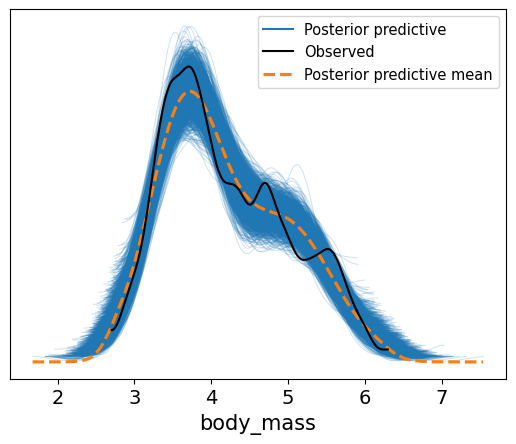

In [16]:
az.plot_ppc(idata_body)

Seems to align pretty well except for the 4-5 region. That's probably where the complexities lie and more of the penguins' body masses are.

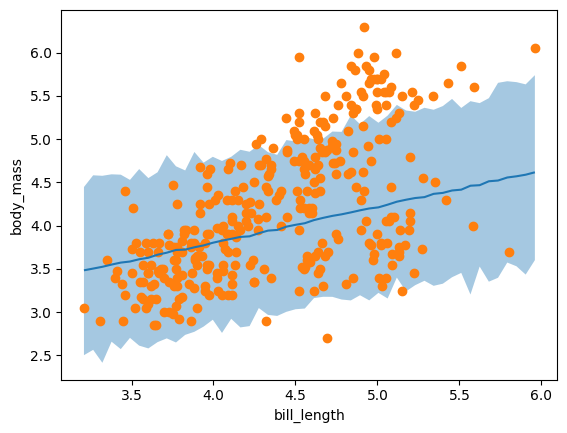

In [21]:
bmb.interpret.plot_predictions(model_body, idata_body, ["bill_length"], pps=True, prob=0.998)
plt.scatter(penguins.bill_length,penguins.body_mass)

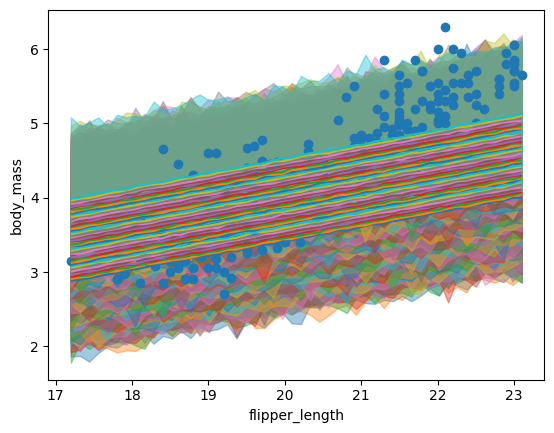

In [22]:

bmb.interpret.plot_predictions(model_body, idata_body, ["flipper_length","bill_depth"], pps=True, prob=0.998, legend=False)
plt.scatter(penguins.flipper_length, penguins.body_mass)

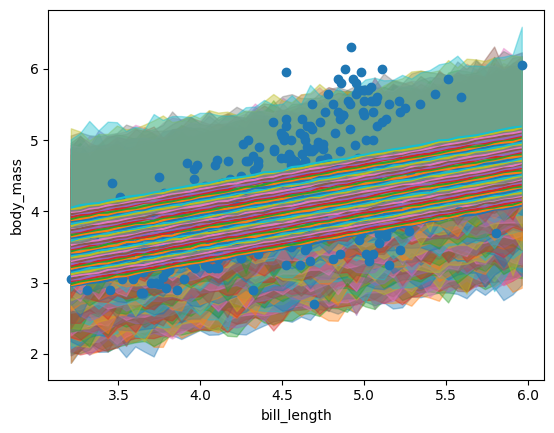

In [23]:

bmb.interpret.plot_predictions(model_body, idata_body, ["bill_length","bill_depth"], pps=True, prob=0.998, legend=False)
plt.scatter(penguins.bill_length, penguins.body_mass)

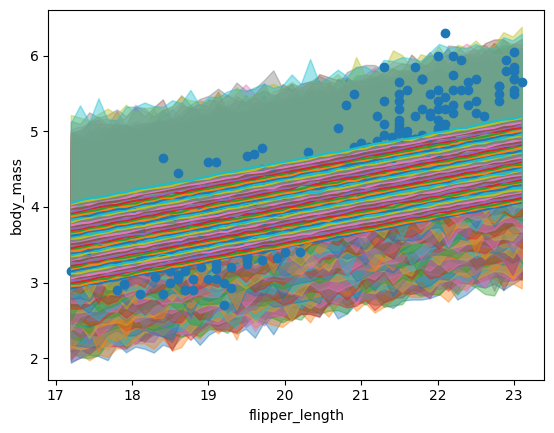

In [24]:

bmb.interpret.plot_predictions(model_body, idata_body, ["flipper_length","bill_length"], pps=True, prob=0.998, legend=False)
plt.scatter(penguins.flipper_length, penguins.body_mass)

nothing that clear or interesting, overall positive association for all variables

**Task5**

Create as many other models as you need to test your causal hypotheses.

Then, "test" those causal hypotheses using the az.compare and az.plot_compare() functions.

In [ ]:
model_nointer = bmb.Model("body_mass ~ bill_depth + flipper_length + bill_length + species", data = penguins, dropna=True)
idata_nointer = model_nointer.fit(idata_kwargs={"log_likelihood":True})

In [ ]:
model_body2 = bmb.Model("body_mass ~ bill_depth:bill_depth + bill_length", data = penguins, dropna=True)
idata_body2 = model_body2.fit(idata_kwargs={"log_likelihood":True})

In [ ]:
model_body3 = bmb.Model("body_mass ~ bill_length:bill_depth + bill_length", data = penguins, dropna=True)
idata_body3 = model_body3.fit(idata_kwargs={"log_likelihood":True})

In [ ]:
model_body4 = bmb.Model("body_mass ~ flipper_length", data = penguins, dropna=True)
idata_body4 = model_body4.fit(idata_kwargs={"log_likelihood":True})

In [34]:
cmp_df = az.compare({"My Hyp.":idata_body,"No Inter":idata_nointer,"two": idata_body2, "three": idata_body3,"four": idata_body4})

<Axes: title={'center': 'Model comparison\nhigher is better'}, xlabel='elpd_loo (log)', ylabel='ranked models'>

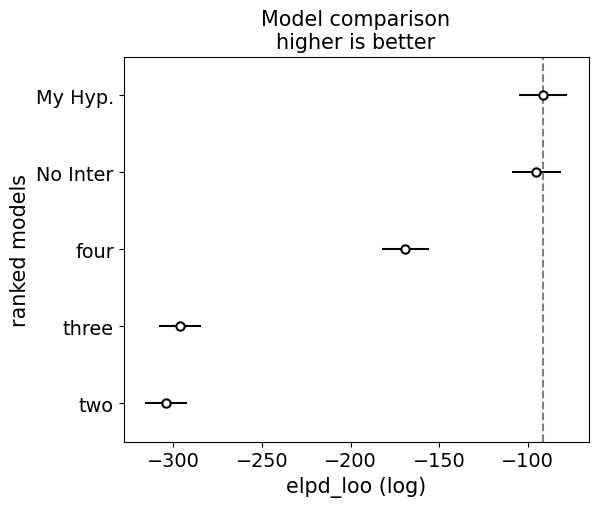

In [35]:
az.plot_compare(cmp_df)

**Task6**

Answer the following:

- Which variables were most important?

- Was that surprising? Why?

- Did the model representing your causal diagram perform worse or better than other models?

- What did you learn about the data--and about penguins--from your models?

Flipper length (model 4) seems the most important. I think that makes sense because the flipper makes up more of a penguin's body than the bill, so a bigger flipper difference contributes a more difference in mass. The model from causal (minus some interactions) performed the best.
The data had holes. Penguin mass depends a lot on flipper length.